In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pymargins import GComputation  # 0.4.0: Margins -> GComputation

rng = np.random.default_rng(1)
n = 180
df = pd.DataFrame({
    "x": rng.normal(0, 1, n),
    "z": rng.normal(0, 1, n),
})
lp = -0.5 + 0.8 * df["x"] - 0.4 * df["z"]
df["y"] = rng.binomial(1, 1 / (1 + np.exp(-lp)))

fit = smf.glm("y ~ x + z", data=df, family=sm.families.Binomial()).fit()
m = GComputation(fit, at="overall", scale="identity")

ame = m.dydx("x")
print(ame.summary())

           Graph Result (delta, level=0.95)          
   estimate  std err       z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------
x    0.1761   0.0360  4.8954  0.000    0.1056, 0.2467

n = 180
Delta-vs-sim disagreement: 6.972%
plan ece0601@1 | κ = 0.124


In [2]:
infl = ame.influence()
infl.shape          # (n_obs,) for a scalar estimand

(180,)

In [3]:
print("sum of influence ≈", float(infl.sum()))

sum of influence ≈ -5.587935447692871e-09


In [4]:
order = np.argsort(-np.abs(infl))
top = df.iloc[order[:5]].copy()
top["influence"] = infl[order[:5]]
print(top)

            x         z  y  influence
30   2.117839  0.501483  0  -0.012894
82  -1.630849 -1.760329  1  -0.010275
108  1.753384 -1.392102  0  -0.009794
174 -1.670850  0.873416  1  -0.009776
155  1.627300 -0.030583  0  -0.008954


In [5]:
se_from_influence = np.sqrt(np.sum(infl ** 2))

m_hc0 = GComputation(fit, at="overall", vcov="HC0", scale="identity")
se_hc0 = float(np.atleast_1d(m_hc0.dydx("x").std_error)[0])

print(f"sqrt(Σ influence²) = {se_from_influence:.6f}")
print(f"HC0 robust SE      = {se_hc0:.6f}")

sqrt(Σ influence²) = 0.036726
HC0 robust SE      = 0.036726


In [6]:
m_boot = GComputation(fit, at="overall", method="bootstrap",
    B=200, seed=0,
    ci="bca", scale="identity")
infl_jack = m_boot.dydx("x").influence()

corr = np.corrcoef(infl, infl_jack)[0, 1]
print(f"correlation(delta, jackknife) = {corr:.4f}")

/home/hunter/Workspace/pymargins/pymargins/estimators/_base.py:176: SoundnessWarning: [tail_count_low] Bootstrap tail count ≈ 5.0 (< 10) at level=0.95: percentile tails are poorly estimated. Increase B or use ci="se".
  self._plan, self._report, self._compiled = compile(


correlation(delta, jackknife) = 0.9525


In [7]:
r_vec = m.predict(atexog={"x": [-1.0, 0.0, 1.0]})
infl_vec = r_vec.influence()
infl_vec.shape

(3, 180)

Text(5, 5, 'obs 30')

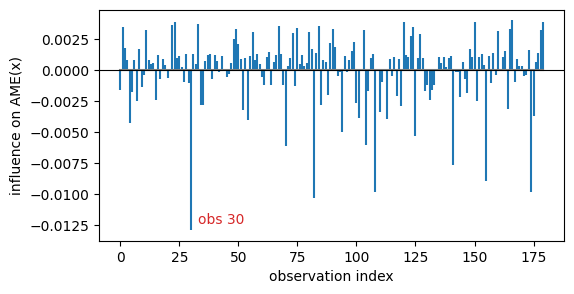

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
ax.stem(np.arange(n), infl, markerfmt=" ", basefmt="C7-")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="observation index", ylabel="influence on AME(x)")
top_i = order[0]
ax.annotate(f"obs {top_i}", (top_i, infl[top_i]),
            textcoords="offset points", xytext=(5, 5), color="C3")